<a href="https://colab.research.google.com/github/deaasanta/MachineLearning/blob/main/Assignment_Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [ ]:
# untuk plot Q-Q
import scipy.stats as stats

In [ ]:
df_california = pd.read_csv('/content/Copy of california_dataset.csv')
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
from sklearn.model_selection import train_test_split
train_clfr, test_clfr = train_test_split(df_california, test_size=0.3, random_state=42)

# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

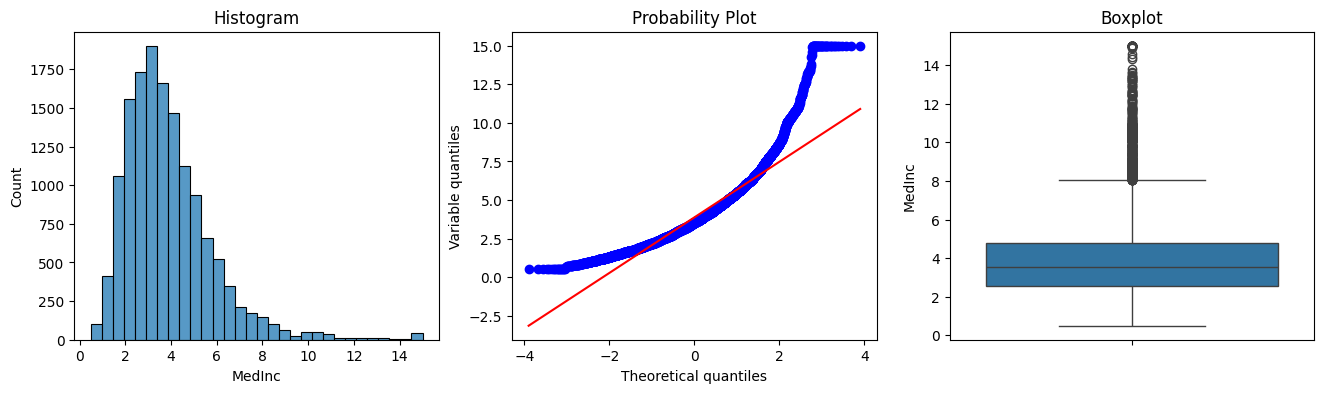

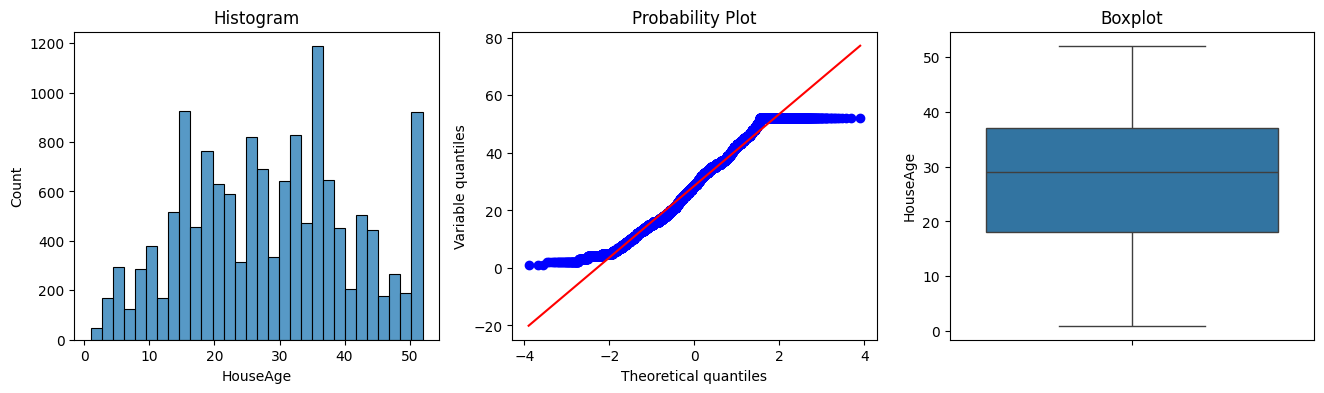

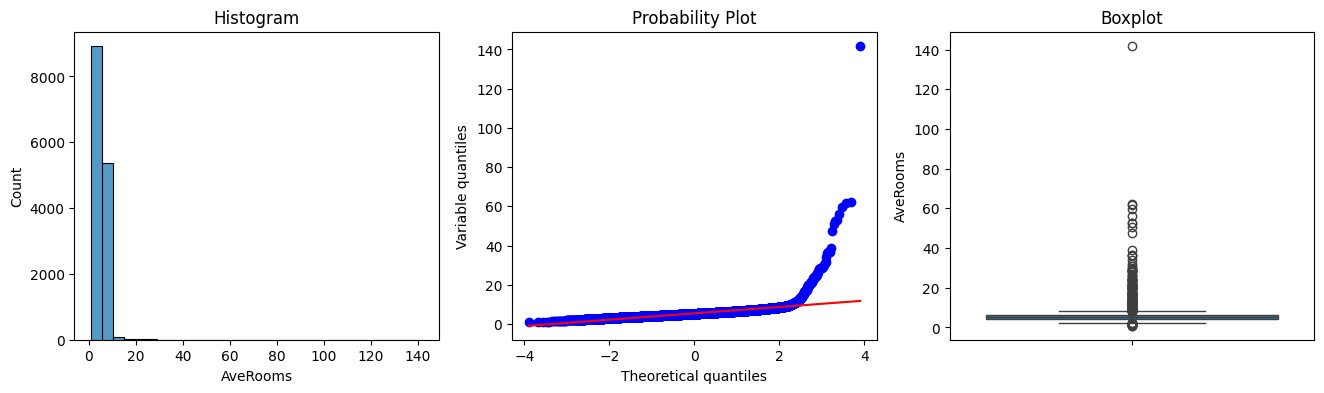

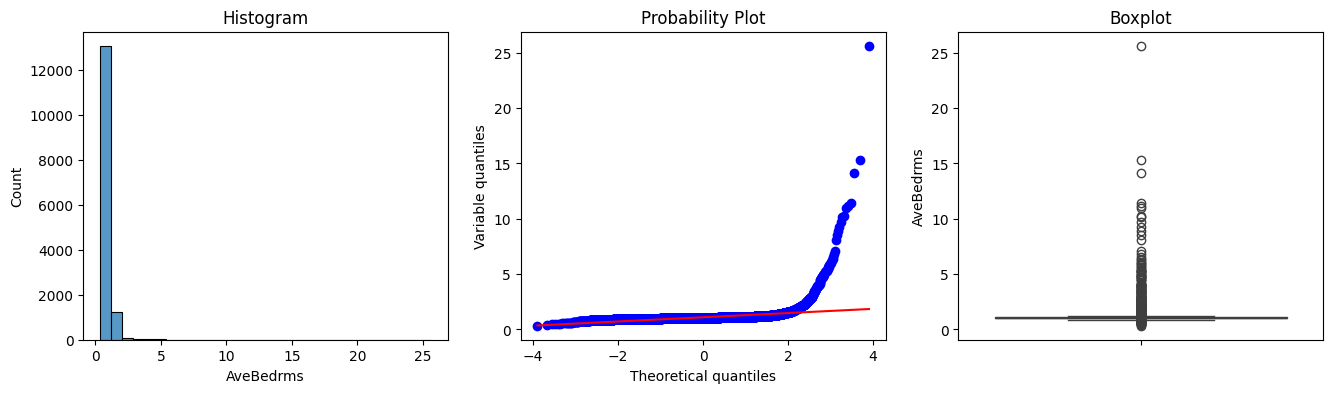

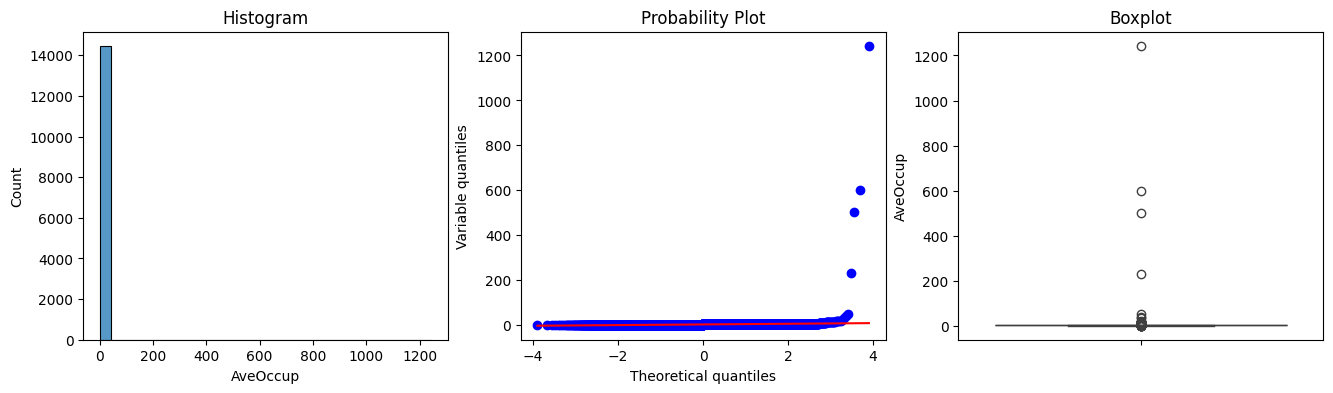

In [ ]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek
for coloum in ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']:
  check_plot(train_clfr, coloum)

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [ ]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali
def find_outlier_boundary(df, variable):

    # Mari kita hitung batas luar yang merupakan outlier

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)

    return upper_boundary, lower_boundary

In [ ]:
MedInc_upper_limit, MedInc_lower_limit = find_outlier_boundary(train_clfr, 'MedInc')
MedInc_upper_limit, MedInc_lower_limit

(np.float64(8.04435), np.float64(-0.7190499999999997))

In [ ]:
import numpy as np
train_clfr['MedInc'] = np.where(
    train_clfr['MedInc'] > MedInc_upper_limit, MedInc_upper_limit,  # Jika lebih besar dari batas atas, ganti dengan batas atas
    np.where(
        train_clfr['MedInc'] < MedInc_lower_limit, MedInc_lower_limit,  # Jika lebih kecil dari batas bawah, ganti dengan batas bawah
        train_clfr['MedInc']  # Jika tidak outlier, biarkan tetap sama
    )
)

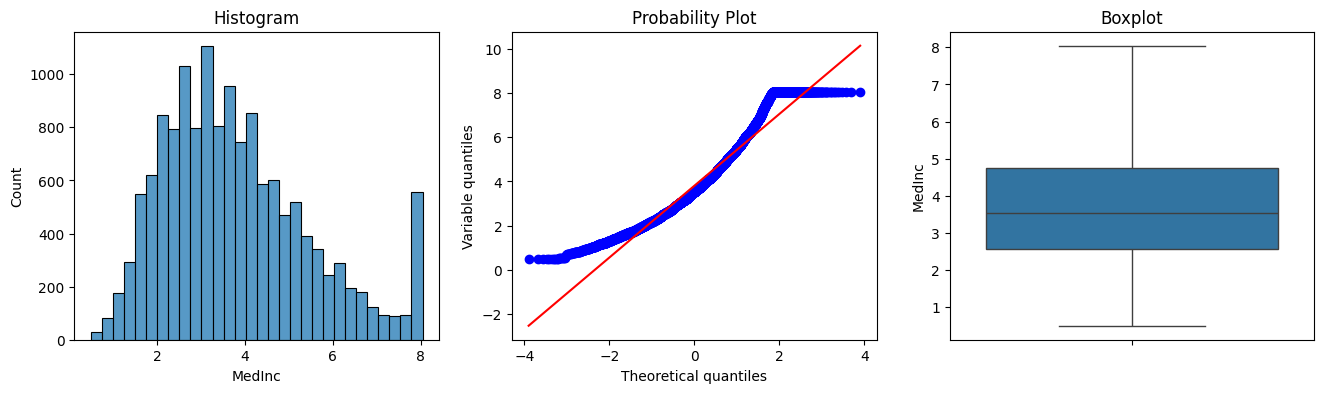

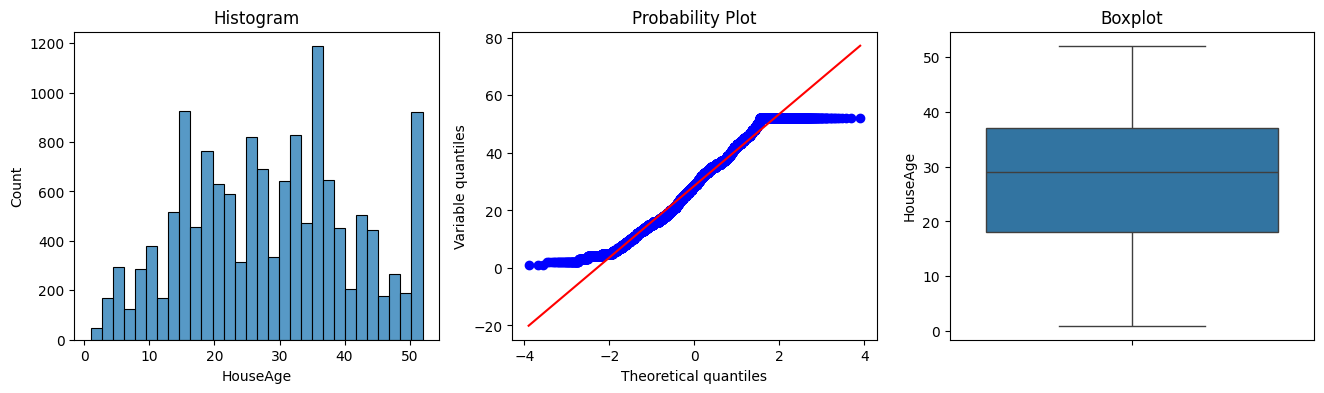

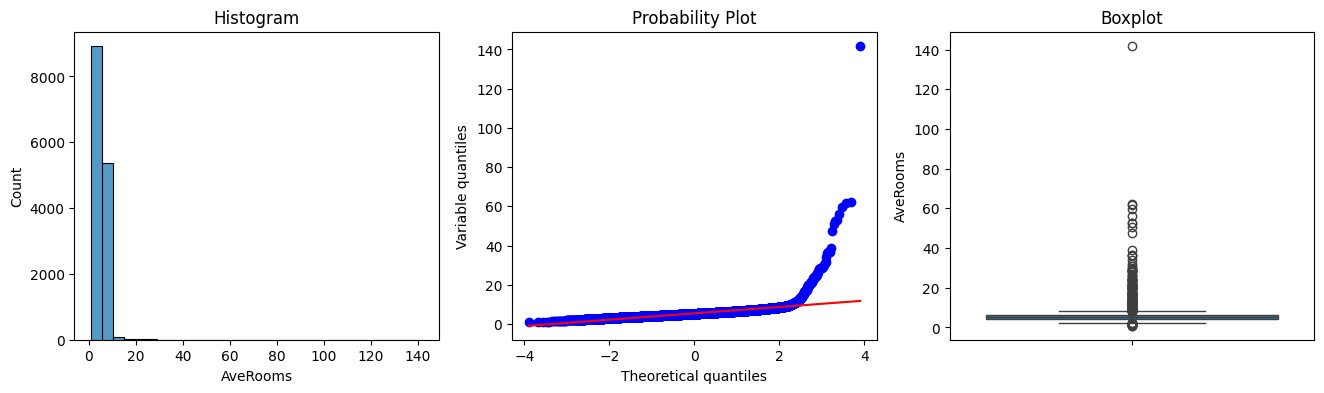

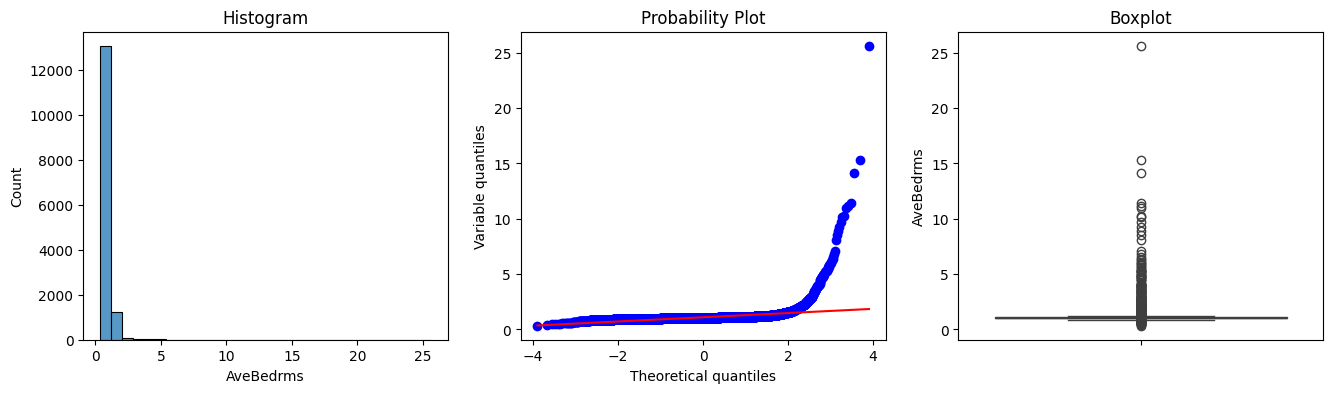

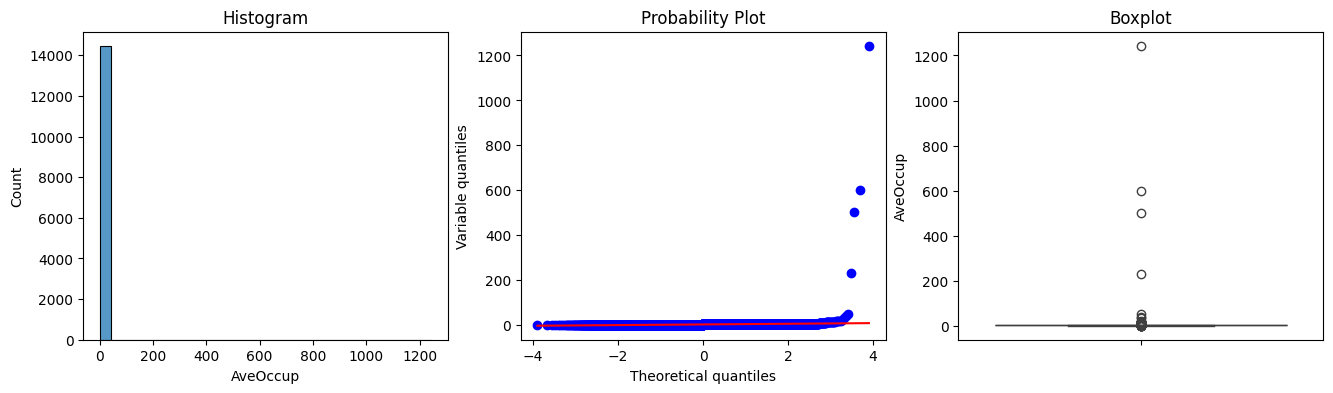

In [ ]:
# Melakukan loop untuk mengecek distribusi tiap kolom
for coloum in ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']:
  check_plot(train_clfr, coloum)

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [ ]:
df_company = pd.read_csv('/content/sample_data/Copy of company.csv')
df_company.head()

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [ ]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
train_company, test_company = train_test_split(df_company, test_size = 0.3, random_state=42)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [ ]:
100 * len(df_company[df_company['Headquarters'].isin(['-1','Unknown / Non-Applicable'])]) / len(df_company)

4.613095238095238

In [ ]:
print(df_company['Headquarters'].dtype)

object


In [ ]:
modus_Headquarters_train = train_company[train_company['Headquarters']!=-1]['Headquarters'].mode()[0]
print(modus_Headquarters_train)

San Francisco, CA


In [ ]:
train_company['Headquarters'] = train_company['Headquarters'].replace('-1',modus_Headquarters_train)
test_company['Headquarters'] = test_company['Headquarters'].replace('-1',modus_Headquarters_train)

In [ ]:
train_company['Headquarters'].value_counts()

,count
Headquarters,
"San Francisco, CA",50
"New York, NY",24
"Chicago, IL",15
"Boston, MA",13
"Westminster, CO",10
"Mc Lean, VA",10
"Cambridge, United Kingdom",7
"San Jose, CA",7
"Reston, VA",7


In [ ]:
test_company['Headquarters'].value_counts()

,count
Headquarters,
"San Francisco, CA",12
"New York, NY",9
"Chicago, IL",8
"Reston, VA",7
"Boston, MA",6
"Basel, Switzerland",5
"Cambridge, MA",4
"Woodbine, MD",4
"Mc Lean, VA",3


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [ ]:
df_churn = pd.read_csv('/content/TelcoCustomerChurn.csv')
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:

from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
train_churn, test_churn = train_test_split(df_churn, test_size = 0.3, random_state=42)

## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [ ]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder
# Kolom-kolom yang ingin di-label encode
columns_to_encode = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()

In [84]:
for col in columns_to_encode:
    train_churn[col] = label_encoder.fit_transform(train_churn[col])

In [85]:
for col in columns_to_encode:
    test_churn[col] = label_encoder.transform(test_churn[col])

In [86]:
train_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1695,4906-ZHGPK,Male,0,Yes,Yes,54,Yes,2,DSL,0,2,0,2,2,0,One year,Yes,Electronic check,70.70,3770,No
1095,7439-DKZTW,Male,0,No,No,1,Yes,0,Fiber optic,0,0,0,0,2,0,Month-to-month,Yes,Electronic check,80.55,80.55,No
3889,2592-HODOV,Male,0,No,No,13,Yes,0,No,1,1,1,1,1,1,One year,No,Credit card (automatic),19.30,259.65,No
3667,7826-VVKWT,Female,1,Yes,Yes,24,Yes,0,Fiber optic,0,0,2,0,2,2,Two year,Yes,Electronic check,96.55,2263.45,No
2902,1658-TJVOA,Female,1,No,No,6,Yes,0,Fiber optic,2,0,0,0,0,0,Month-to-month,Yes,Electronic check,74.10,450.9,No


In [87]:
test_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,1,DSL,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,2,No,0,0,0,0,0,0,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,0,No,0,0,0,0,0,0,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,0,Fiber optic,0,0,2,0,0,0,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,0,DSL,0,0,0,2,0,0,Two year,No,Bank transfer (automatic),50.55,3260.1,No


## Selesai :)